In [10]:
import sys
import pandas as pd
import plotly.graph_objects as go
import os

def plot_jitter_data(file_path):
    """
    Reads a CSV file, calculates a rolling mean for SmplJitter,
    and plots the data using Plotly.
    """
    
    # 1. Validation: Check if file exists
    if not os.path.exists(file_path):
        print(f"Error: The file '{file_path}' was not found.")
        return

    try:
        # 2. Load Data
        # Parsing 'timestamp' ensures plotly handles the x-axis time-scaling correctly
        df = pd.read_csv(file_path, parse_dates=['timestamp'])
        
        # 3. Calculate Sliding Window Mean
        # We use a window of 300 samples. 'min_periods=1' ensures the line starts 
        # immediately rather than waiting for sample 300 to appear.
        window_size = 300
        df['Jitter_Rolling_Mean'] = df['SmplJitter'].rolling(window=window_size, min_periods=1).mean()

        # 4. Create Plot
        fig = go.Figure()

        # Add the Raw Data Trace (Light Blue)
        fig.add_trace(go.Scatter(
            x=df['timestamp'],
            y=df['SmplJitter'],
            mode='lines',
            name='Sample Jitter',
            line=dict(color='lightblue', width=1.5),
            opacity=0.7
        ))

        # Add the Rolling Mean Trace (Red)
        fig.add_trace(go.Scatter(
            x=df['timestamp'],
            y=df['Jitter_Rolling_Mean'],
            mode='lines',
            name=f'Mean (window={window_size})',
            line=dict(color='red', width=2.5)
        ))

        # 5. Layout Styling
        fig.update_layout(
            title=f'Sample Jitter vs Time (File: {os.path.basename(file_path)})',
            xaxis_title='Timestamp',
            yaxis_title='Jitter',
            template='plotly_white', # Clean white background
            hovermode="x unified",   # Shows values for both lines when hovering
            legend=dict(
                yanchor="top",
                y=0.99,
                xanchor="left",
                x=0.01
            )
        )

        fig.show()

    except Exception as e:
        print(f"An error occurred while processing the file: {e}")




Error: The file '-f' was not found.


In [6]:
path = "../data/no-l2-pqos/07-19-59"

In [14]:
plot_jitter_data(path)

In [20]:
import pandas as pd
import plotly.graph_objects as go
import os
import json

def plot_benchmark_folder(folder_path):
    """
    Looks for 'output.csv' and 'sysinfo.json' in the given folder,
    plots SmplJitter with a sliding mean, and displays metadata.
    
    Args:
        folder_path (str): Path to the folder containing the results.
    """
    
    # --- 1. Construct File Paths ---
    csv_path = os.path.join(folder_path, 'output.csv')
    json_path = os.path.join(folder_path, 'sysinfo.json')

    # --- 2. Validation ---
    if not os.path.isdir(folder_path):
        print(f"Error: Folder not found: {folder_path}")
        return
    
    if not os.path.exists(csv_path):
        print(f"Error: 'output.csv' not found in {folder_path}")
        return
        
    # --- 3. Load & Format JSON Metadata ---
    meta_text = "<b>METADATA MISSING</b>" # Default if JSON is missing
    
    if os.path.exists(json_path):
        try:
            with open(json_path, 'r') as f:
                data = json.load(f)

            hydra = data.get('hydra', {})
            run = hydra.get('run', {})
            pqos = hydra.get('pqos', {}).get('classes', [])
            
            # Run Config
            meta_text = "<b>RUN CONFIGURATION</b><br>"
            meta_text += f"Command: {run.get('command', 'N/A')}<br>"
            meta_text += f"Test Cores: {run.get('t_core', 'N/A')}<br>"
            meta_text += "<br><b>PQOS CLASSES</b><br>"
            
            # PQOS Classes
            for q_class in pqos:
                cores = q_class.get('cores', [])
                # Compact core list representation
                cores_str = str(cores).replace('[', '').replace(']', '')
                if len(cores_str) > 25: 
                     cores_str = cores_str[:25] + "..."
                     
                meta_text += f"<b>ID {q_class.get('id')}: {q_class.get('description', 'N/A')}</b><br>"
                meta_text += f"&nbsp;L3: {q_class.get('l3_mask')} | MBA: {q_class.get('mba')}%<br>"
                meta_text += f"&nbsp;Cores: {cores_str}<br>"
                meta_text += "<br>"
        except Exception as e:
            meta_text = f"<b>Error reading JSON:</b><br>{str(e)}"
    else:
        print(f"Warning: 'sysinfo.json' not found in {folder_path}. Plotting data without metadata.")

    # --- 4. Load CSV & Process Data ---
    df = pd.read_csv(csv_path, parse_dates=['timestamp'])
    
    window_size = 300
    df['Mean'] = df['SmplJitter'].rolling(window=window_size, min_periods=1).mean()

    # --- 5. Build Plot ---
    fig = go.Figure()

    # Trace 1: Raw Jitter
    fig.add_trace(go.Scatter(
        x=df['timestamp'], y=df['SmplJitter'],
        mode='lines', name='Sample Jitter',
        line=dict(color='lightblue', width=1.5), opacity=0.7
    ))

    # Trace 2: Rolling Mean
    fig.add_trace(go.Scatter(
        x=df['timestamp'], y=df['Mean'],
        mode='lines', name=f'Mean (win={window_size})',
        line=dict(color='red', width=2.5)
    ))

    # --- 6. Layout ---
    fig.update_layout(
        title=f'Jitter Analysis<br><sup>Folder: {folder_path}</sup>',
        xaxis_title='Timestamp',
        yaxis_title='Jitter',
        template='plotly_white',
        height=600,
        margin=dict(r=260), # Right margin for text box
        legend=dict(x=0.01, y=0.99, bgcolor='rgba(255,255,255,0.8)'),
        annotations=[
            dict(
                text=meta_text,
                align='left',
                showarrow=False,
                xref='paper', yref='paper',
                x=1.02, y=1,
                xanchor='left', yanchor='top',
                font=dict(size=10, family="Consolas, monospace"),
                bordercolor="#333", borderwidth=1,
                bgcolor="#f4f4f4", opacity=0.9
            )
        ]
    )

    fig.show()    

In [ ]:
path = "../data/no-l2-pqos/07-19-59"

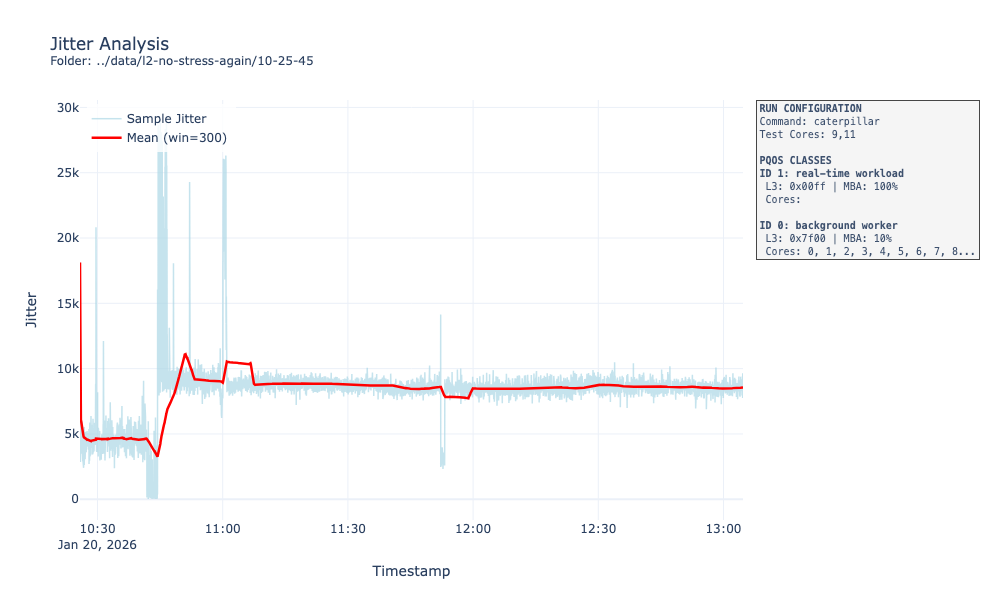

In [21]:
plot_benchmark_folder(path)